<a href="https://colab.research.google.com/github/sunputawan/Bank-Churn-Prediction/blob/main/Bank_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1) LOAD DATA


In [2]:
import pandas as pd

df = pd.read_csv('Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


---
<br><br><br>
#2) EDA

In [3]:
df.shape


(10000, 14)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


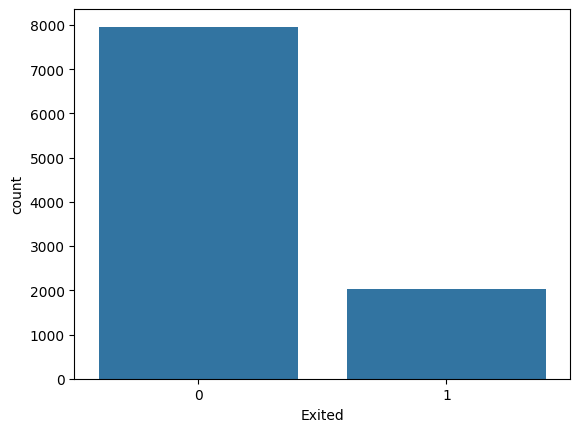

,proportion
Exited,
0,0.7963
1,0.2037


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Exited', data=df)
plt.show()

df['Exited'].value_counts(normalize=True)

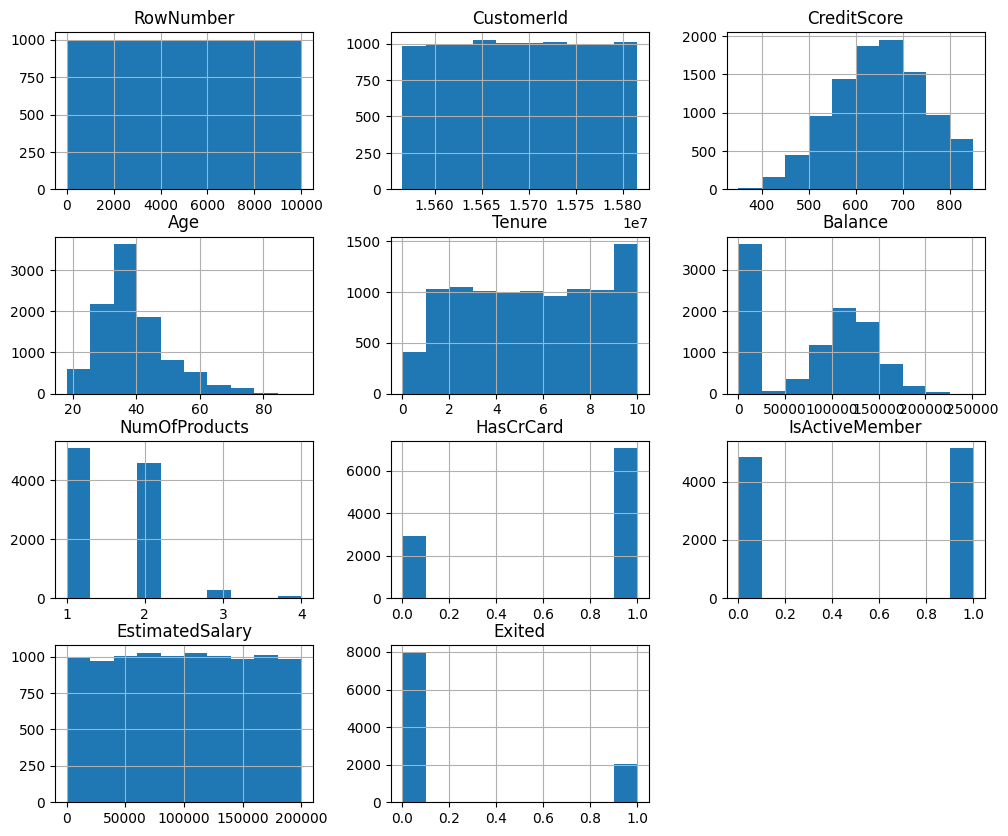

In [7]:
# Distribution of numberic features

df.hist(figsize=(12, 10))
plt.show()

In [8]:
df.groupby('Exited')[['Age', 'Balance', 'NumOfProducts', 'IsActiveMember']].mean()

,Age,Balance,NumOfProducts,IsActiveMember
Exited,,,,
0,37.408389,72745.296779,1.544267,0.554565
1,44.837997,91108.539337,1.475209,0.360825


In [9]:
df['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [10]:
df['Gender'].value_counts()

,count
Gender,
Male,5457
Female,4543


---
<br><br><br>
#3) Preprocessing

In [11]:
# Drop unnecessary columns

df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])
df.shape

(10000, 11)

In [12]:
# Feature Engineering

df['HasBalance'] = (df['Balance'] > 0).astype(int)
df.shape

(10000, 12)

In [13]:
# Encode Categorical Columns
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,HasBalance,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,1,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,1,False,True,False


In [14]:
# Seperate X and y
X = df.drop(columns=['Exited'])
y = df['Exited']

In [15]:
# Split train and test set
from sklearn.model_selection import train_test_split



X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(8000, 12) (2000, 12)


In [16]:
# Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
X_train

array([[ 0.35649971, -0.6557859 ,  0.34567966, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [-0.20389777,  0.29493847, -0.3483691 , ...,  1.72572313,
        -0.57638802,  0.91324755],
       [-0.96147213, -1.41636539, -0.69539349, ..., -0.57946723,
         1.73494238,  0.91324755],
       ...,
       [ 0.86500853, -0.08535128, -1.38944225, ..., -0.57946723,
        -0.57638802, -1.09499335],
       [ 0.15932282,  0.3900109 ,  1.03972843, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [ 0.47065475,  1.15059039, -1.38944225, ...,  1.72572313,
        -0.57638802,  0.91324755]])

---
<br><br><br>
#4) Training

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [19]:
# Logistic Regression

lr = LogisticRegression(class_weight='balanced', random_state=42)
lr.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', random_state=42)

In [20]:
# Random Forest

rf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [21]:
# XGBoost

xgb = XGBClassifier(random_state=42)
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

---
<br><br><br>
#5) Evaluate

In [22]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, recall_score

models = {'Logistic Regression': lr, 'Random Forest': rf, 'XGBoost': xgb}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"=== {name} ===")
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
    print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")
    print()

=== Logistic Regression ===
Accuracy : 0.7215
Recall   : 0.7125
F1 Score : 0.5013
ROC-AUC  : 0.7816

=== Random Forest ===
Accuracy : 0.8695
Recall   : 0.4606
F1 Score : 0.5811
ROC-AUC  : 0.8568

=== XGBoost ===
Accuracy : 0.8605
Recall   : 0.5191
F1 Score : 0.5939
ROC-AUC  : 0.8533



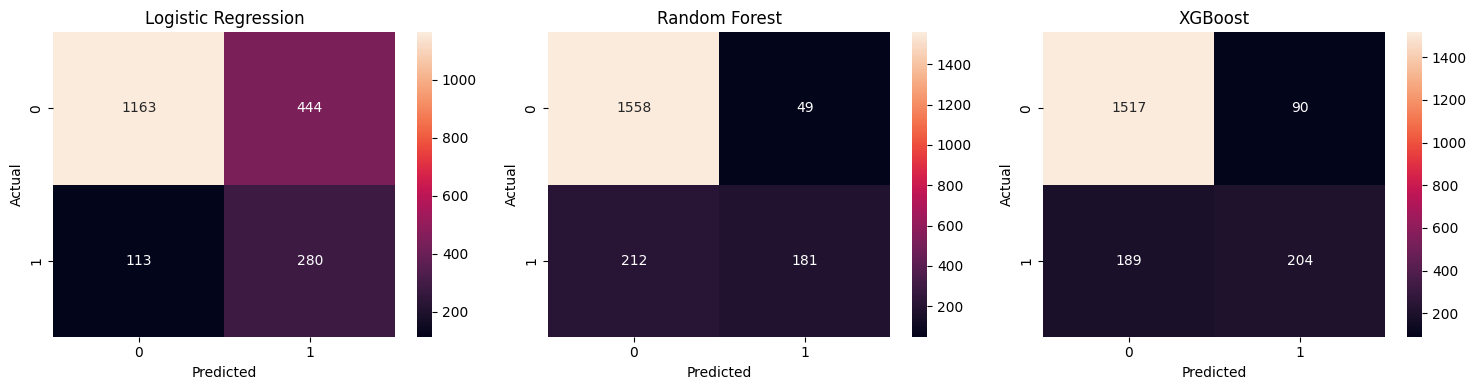

In [23]:
# Confusion Matrix

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

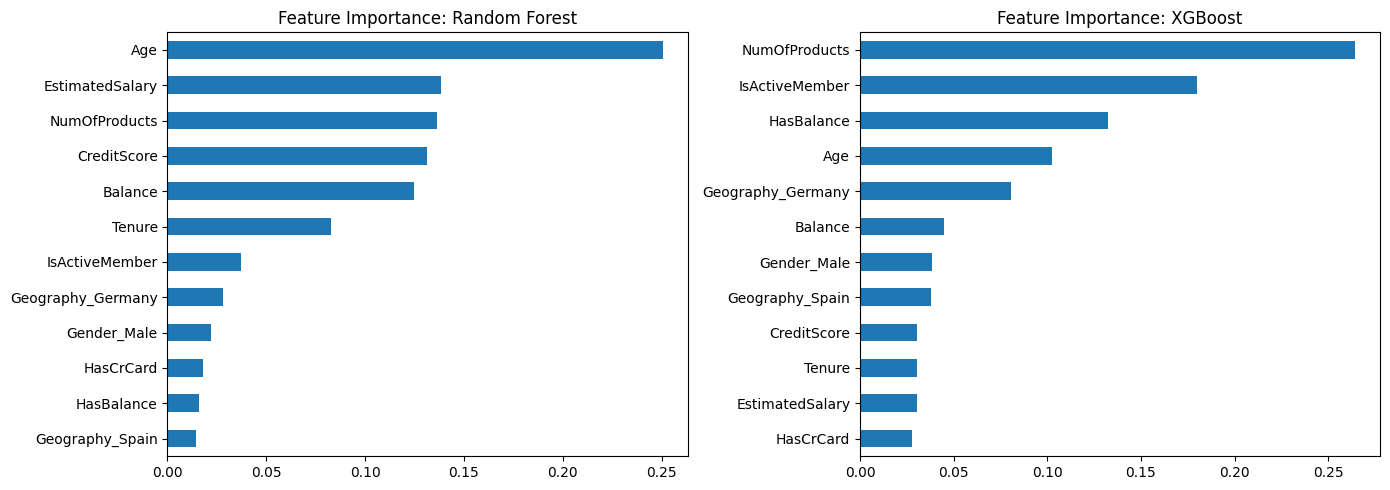

In [24]:
# Feature Importance

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, model) in zip(axes, {'Random Forest': rf, 'XGBoost': xgb}.items()):
    importance = pd.Series(model.feature_importances_, index=X.columns)
    importance.sort_values().plot(kind='barh', ax=ax)
    ax.set_title(f'Feature Importance: {name}')

plt.tight_layout()
plt.show()

---
<br><br><br>
#6) Hyperparameter Tuning

In [25]:
# Logistic Regression
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'max_iter': [100, 200, 500],
}

grid_lr = GridSearchCV(
    LogisticRegression(class_weight='balanced', random_state=42),
    param_grid_lr,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_lr.fit(X_train, y_train)
print("LR Best params:", grid_lr.best_params_)
print("LR Best AUC:", grid_lr.best_score_)

NameError: name 'GridSearchCV' is not defined

In [ ]:
# Random Forest
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
}

grid_rf = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid_rf,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)
print("RF Best params:", grid_rf.best_params_)
print("RF Best AUC:", grid_rf.best_score_)

In [ ]:
# XGBoost
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
}

grid_xgb = GridSearchCV(
    XGBClassifier(random_state=42),
    param_grid_xgb,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train, y_train)
print("XGBoost Best params:", grid_xgb.best_params_)
print("XGBoost Best AUC:", grid_xgb.best_score_)

In [ ]:
# Evaluation after tuning
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, recall_score

tuned_models = {
    'Logistic Regression': grid_lr.best_estimator_,
    'Random Forest': grid_rf.best_estimator_,
    'XGBoost': grid_xgb.best_estimator_,
}

for name, model in tuned_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"=== {name} ===")
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
    print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")
    print()

In [ ]:
# Confusion Matrix after tuning

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, tuned_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax)
    ax.set_title(f'{name} (Tuned)')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [ ]:
# Metric Comparison Bar Chart

results = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [0.7215, 0.8455, 0.8695],
    'Recall':   [0.7125, 0.6743, 0.5038],
    'F1':       [0.5013, 0.6317, 0.6027],
    'ROC-AUC':  [0.7818, 0.8677, 0.8736],
}

results_df = pd.DataFrame(results).set_index('Model')

results_df.plot(kind='bar', figsize=(10, 5), ylim=(0, 1))
plt.title('Model Comparison (After Tuning)')
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
# ROC Curve
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

for name, model in tuned_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

In [ ]:
!pip install shap

import shap

explainer = shap.TreeExplainer(grid_xgb.best_estimator_)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, feature_names=list(X.columns))

---
<br><br><br>
#Conclusion

XGBoost achieved the best overall performance with ROC-AUC of 0.8736, meaning it correctly ranks a churning customer above a non-churning one 87% of the time.

However, if the bank's priority is to catch as many churners as possible, Random Forest may be the better choice due to its higher Recall (0.67 vs 0.50) — meaning it captures 67% of actual churners compared to XGBoost's 50%.





## From SHAP analysis, the top drivers of churn are:

1. Age — older customers are more likely to churn
2. NumOfProducts — surprisingly, having more products increases churn risk, possibly indicating over-cross-selling dissatisfaction
3. IsActiveMember — inactive members churn significantly more


Business recommendation - the bank should focus retention efforts on customers who are <b>older, inactive, and hold multiple products</b>, as this segment carries the highest churn risk. Early intervention with this group could meaningfully reduce customer loss.